#### Importing Data Object

In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
import squidpy as sq
import numpy as np

print(ad.__version__)
print(sc.__version__)
print(sq.__version__)

/Users/evangrosso/Library/r-miniconda-arm64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.13.2
1.12.3
1.8.3


/var/folders/wb/91fy7plj3mjf6_jnysc4v_kc0000gn/T/ipykernel_38949/4171244509.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(ad.__version__)
/var/folders/wb/91fy7plj3mjf6_jnysc4v_kc0000gn/T/ipykernel_38949/4171244509.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


#### Importing Data from .h5ad

In [2]:
adata = sc.read_h5ad("slv14.h5ad")
adata

sq.gr.spatial_neighbors_grid(adata, spatial_key = "spatial", n_neighs = 4, n_rings = 1)

INFO     Creating graph using `None` transform and `1` libraries.                                                  


#### Converting Phenotype Classifiers to Masks

In [9]:
CD4 = (adata.obs["CD4_status"] == "CD4").to_numpy()
CD8 = (adata.obs["CD8_status"] == "CD8").to_numpy()
ISC = (adata.obs["ISC_status"] == "ISC").to_numpy()

ISC_MHCII_rich = (adata.obs["ISC_MHCII_status"] == "ISC-MHCII rich").to_numpy()
ISC_MHCII_poor = (adata.obs["ISC_MHCII_status"] == "ISC-MHCII poor").to_numpy()

ISC_MHCI_rich = (adata.obs["ISC_MHCI_status"] == "ISC-MHCI rich").to_numpy()
ISC_MHCI_poor = (adata.obs["ISC_MHCI_status"] == "ISC-MHCI poor").to_numpy()

n_identities = (
    CD4.astype(int)
    + CD8.astype(int)
    + ISC_MHCII_rich.astype(int)
    + ISC_MHCII_poor.astype(int)
)

adata.obs["proximity_group"] = "Other"

adata.obs.loc[CD4, "proximity_group"] = "CD4"
adata.obs.loc[CD8, "proximity_group"] = "CD8"
adata.obs.loc[ISC_MHCII_rich, "proximity_group"] = "ISC-MHCII rich"
adata.obs.loc[ISC_MHCII_poor, "proximity_group"] = "ISC-MHCII poor"

adata.obs.loc[n_identities > 1, "proximity_group"] = "Ambiguous"

adata.obs["proximity_group"] = (
    adata.obs["proximity_group"]
    .fillna("Other")
    .astype("category")
)
n_ambiguous = (adata.obs["proximity_group"] == "Ambiguous").sum()

print("Ambiguous bins:", n_ambiguous)
print(
    "Percent ambiguous:",
    100 * n_ambiguous / adata.n_obs
)

print("CD4 + CD8:",
      (CD4 & CD8).sum())

print("CD4 + ISC-MHCII rich:",
      (CD4 & ISC_MHCII_rich).sum())

print("CD4 + ISC-MHCII poor:",
      (CD4 & ISC_MHCII_poor).sum())

print("CD8 + ISC-MHCII rich:",
      (CD8 & ISC_MHCII_rich).sum())

print("CD8 + ISC-MHCII poor:",
      (CD8 & ISC_MHCII_poor).sum())

Ambiguous bins: 2291
Percent ambiguous: 3.1038734064028395
CD4 + CD8: 627
CD4 + ISC-MHCII rich: 620
CD4 + ISC-MHCII poor: 745
CD8 + ISC-MHCII rich: 227
CD8 + ISC-MHCII poor: 282


#### Spatial Graph Analysis

100%|██████████| 1000/1000 [00:08<00:00, 118.89/s]


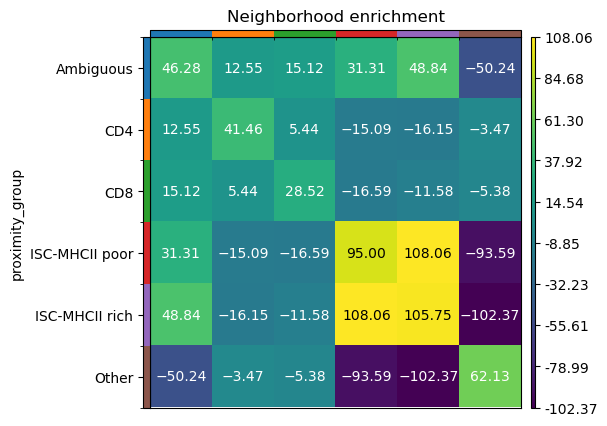

In [10]:
sq.gr.nhood_enrichment(
    adata,
    cluster_key="proximity_group",
    n_perms=1000,
    seed=42
)

sq.pl.nhood_enrichment(
    adata,
    cluster_key="proximity_group",
    annotate=True
)